# Comparação de Modelos e Hiperparâmetros — Detecção de Anomalias

1. **Arquiteturas diferentes** de autoencoder (raso, profundo, largo/latente maior);
2. **Modelos totalmente diferentes** (Autoencoder padrão, Variational Autoencoder e
   Denoising Autoencoder);
3. **Hiperparâmetros diferentes** (taxa de aprendizado, batch size, número de épocas)
   aplicados ao melhor modelo encontrado (fase B).

No final, todos os experimentos são reunidos numa tabela comparativa e o melhor
modelo é usado para a detecção de anomalias (limiar no percentil 95). Também é feito
uma análise geral dos resultados.


In [1]:
import time
import itertools

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


Dispositivo em uso: cuda


## 1. Dados

In [2]:
data = torch.load("../../src/data/bidding_tensors.pt", weights_only=True)

dataset = TensorDataset(data)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(
    dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(SEED),
)

input_dim = data.shape[1]
print(f"Total de amostras: {len(dataset)}")
print(f"Treino: {len(train_dataset)} | Teste: {len(test_dataset)}")
print(f"Dimensão de entrada: {input_dim}")


Total de amostras: 6152
Treino: 4921 | Teste: 1231
Dimensão de entrada: 1


## 2. Modelos

- `AutoEncoder`: arquitetura genérica e configurável (permite testar raso/profundo/latente maior
  passando `hidden_dims` e `latent_dim` diferentes — é o mesmo `AnomalyAutoEncoder` do notebook
  original quando `hidden_dims=[16, 8]` e `latent_dim=4`).
- `VariationalAutoEncoder` (VAE): aprende uma distribuição latente (média/log-variância) em vez de
  um vetor fixo, com perda = reconstrução + divergência KL.
- `DenoisingAutoEncoder`: recebe entrada com ruído gaussiano durante o treino e aprende a
  reconstruir a versão limpa — parte de um princípio diferente (robustez a ruído) e costuma
  generalizar melhor para detecção de anomalias.


In [3]:
class AutoEncoder(nn.Module):
    """Autoencoder genérico. hidden_dims define as camadas intermediárias do encoder
    (o decoder usa a ordem espelhada)."""

    def __init__(self, input_dim: int, hidden_dims=(16, 8), latent_dim: int = 4):
        super().__init__()
        dims = [input_dim, *hidden_dims, latent_dim]
        enc_layers = []
        for i in range(len(dims) - 1):
            enc_layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                enc_layers.append(nn.ReLU())
        self.encoder = nn.Sequential(*enc_layers)

        rev_dims = dims[::-1]
        dec_layers = []
        for i in range(len(rev_dims) - 1):
            dec_layers.append(nn.Linear(rev_dims[i], rev_dims[i + 1]))
            if i < len(rev_dims) - 2:
                dec_layers.append(nn.ReLU())
        self.decoder = nn.Sequential(*dec_layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed


class VariationalAutoEncoder(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(16, 8), latent_dim: int = 4):
        super().__init__()
        dims = [input_dim, *hidden_dims]
        enc_layers = []
        for i in range(len(dims) - 1):
            enc_layers.append(nn.Linear(dims[i], dims[i + 1]))
            enc_layers.append(nn.ReLU())
        self.encoder_body = nn.Sequential(*enc_layers)
        self.fc_mu = nn.Linear(dims[-1], latent_dim)
        self.fc_logvar = nn.Linear(dims[-1], latent_dim)

        rev_dims = [latent_dim, *dims[::-1]]
        dec_layers = []
        for i in range(len(rev_dims) - 1):
            dec_layers.append(nn.Linear(rev_dims[i], rev_dims[i + 1]))
            if i < len(rev_dims) - 2:
                dec_layers.append(nn.ReLU())
        self.decoder = nn.Sequential(*dec_layers)

    def encode(self, x):
        h = self.encoder_body(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decoder(z)
        return reconstructed, mu, logvar


class DenoisingAutoEncoder(AutoEncoder):
    """Mesma arquitetura do AutoEncoder, mas soma ruído gaussiano à entrada
    durante o treino (o alvo continua sendo a entrada original, sem ruído)."""

    def __init__(self, input_dim: int, hidden_dims=(16, 8), latent_dim: int = 4, noise_std: float = 0.1):
        super().__init__(input_dim, hidden_dims, latent_dim)
        self.noise_std = noise_std

    def forward(self, x: torch.Tensor, add_noise: bool = False) -> torch.Tensor:
        x_in = x
        if add_noise and self.training:
            x_in = x + torch.randn_like(x) * self.noise_std
        return super().forward(x_in)


def vae_loss(reconstructed, x, mu, logvar):
    recon_loss = F.mse_loss(reconstructed, x, reduction="mean")
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld


## 3. Função de treino genérica

Uma única função treina qualquer um dos três tipos de modelo (`"ae"`, `"vae"`,
`"denoising"`), recebendo os hiperparâmetros do experimento e devolvendo o
histórico de perdas, o tempo de treino e o modelo treinado.


In [4]:
def build_model(model_type: str, hidden_dims, latent_dim: int, noise_std: float = 0.1):
    if model_type == "ae":
        return AutoEncoder(input_dim, hidden_dims=hidden_dims, latent_dim=latent_dim)
    elif model_type == "vae":
        return VariationalAutoEncoder(input_dim, hidden_dims=hidden_dims, latent_dim=latent_dim)
    elif model_type == "denoising":
        return DenoisingAutoEncoder(input_dim, hidden_dims=hidden_dims, latent_dim=latent_dim, noise_std=noise_std)

def train_experiment(name, model_type="ae", hidden_dims=(16, 8), latent_dim=4,
                      lr=1e-3, batch_size=32, epochs=100, noise_std=0.1, verbose=False):
    torch.manual_seed(SEED)

    model = build_model(model_type, hidden_dims, latent_dim, noise_std).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    history_train, history_val = [], []
    start = time.time()

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            x = batch[0].to(device)
            optimizer.zero_grad()

            if model_type == "vae":
                reconstructed, mu, logvar = model(x)
                loss = vae_loss(reconstructed, x, mu, logvar)
            elif model_type == "denoising":
                reconstructed = model(x, add_noise=True)
                loss = criterion(reconstructed, x)
            else:
                reconstructed = model(x)
                loss = criterion(reconstructed, x)

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in test_loader:
                x = batch[0].to(device)
                if model_type == "vae":
                    reconstructed, mu, logvar = model(x)
                    loss = vae_loss(reconstructed, x, mu, logvar)
                elif model_type == "denoising":
                    reconstructed = model(x, add_noise=False)
                    loss = criterion(reconstructed, x)
                else:
                    reconstructed = model(x)
                    loss = criterion(reconstructed, x)
                val_loss += loss.item()

        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(test_loader)
        history_train.append(avg_train)
        history_val.append(avg_val)

        if verbose and (epoch + 1) % max(1, epochs // 5) == 0:
            print(f"  [{name}] epoch {epoch + 1}/{epochs} | train={avg_train:.6f} | val={avg_val:.6f}")

    elapsed = time.time() - start

    result = {
        "name": name,
        "model_type": model_type,
        "hidden_dims": str(hidden_dims),
        "latent_dim": latent_dim,
        "lr": lr,
        "batch_size": batch_size,
        "epochs": epochs,
        "final_train_loss": history_train[-1],
        "final_val_loss": history_val[-1],
        "train_time_s": elapsed,
        "history_train": history_train,
        "history_val": history_val,
        "model": model,
    }
    return result


## 4. Etapa A — Comparando arquiteturas e tipos de modelo

Hiperparâmetros de treino fixos (`lr=1e-3`, `batch_size=32`, `epochs=60`) para
isolar o efeito da arquitetura/tipo de modelo. Ajuste `epochs` conforme o tempo
disponível.


In [5]:
architecture_configs = [
    {"name": "AE_raso",       "model_type": "ae",         "hidden_dims": (8,),      "latent_dim": 3},
    {"name": "AE_baseline",   "model_type": "ae",         "hidden_dims": (16, 8),   "latent_dim": 4},
    {"name": "AE_profundo",   "model_type": "ae",         "hidden_dims": (32, 16, 8), "latent_dim": 4},
    {"name": "AE_latente_maior", "model_type": "ae",      "hidden_dims": (16, 8),   "latent_dim": 8},
    {"name": "VAE_baseline",  "model_type": "vae",        "hidden_dims": (16, 8),   "latent_dim": 4},
    {"name": "Denoising_AE",  "model_type": "denoising",  "hidden_dims": (16, 8),   "latent_dim": 4, "noise_std": 0.1},
]

FIXED_LR = 1e-3
FIXED_BATCH = 32
FIXED_EPOCHS = 60

architecture_results = []
for cfg in architecture_configs:
    print(f"Treinando: {cfg['name']} ...")
    res = train_experiment(
        name=cfg["name"],
        model_type=cfg["model_type"],
        hidden_dims=cfg["hidden_dims"],
        latent_dim=cfg["latent_dim"],
        lr=FIXED_LR,
        batch_size=FIXED_BATCH,
        epochs=FIXED_EPOCHS,
        noise_std=cfg.get("noise_std", 0.1),
    )
    architecture_results.append(res)

print("Concluído!")


Treinando: AE_raso ...
Treinando: AE_baseline ...
Treinando: AE_profundo ...
Treinando: AE_latente_maior ...
Treinando: VAE_baseline ...
Treinando: Denoising_AE ...
Concluído!


In [6]:
df_arch = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("history_train", "history_val", "model")}
    for r in architecture_results
]).sort_values("final_val_loss").reset_index(drop=True)

df_arch


,name,model_type,hidden_dims,latent_dim,lr,batch_size,epochs,final_train_loss,final_val_loss,train_time_s
0,Denoising_AE,denoising,"(16, 8)",4,0.001,32,60,0.147951,0.001009,14.558675
1,AE_profundo,ae,"(32, 16, 8)",4,0.001,32,60,0.603813,0.003125,18.724454
2,AE_raso,ae,"(8,)",3,0.001,32,60,0.233335,0.019183,13.516740
3,AE_baseline,ae,"(16, 8)",4,0.001,32,60,0.084384,0.029139,15.838920
4,AE_latente_maior,ae,"(16, 8)",8,0.001,32,60,1.122157,2.204772,14.919457
5,VAE_baseline,vae,"(16, 8)",4,0.001,32,60,72.570705,50.483215,21.656879


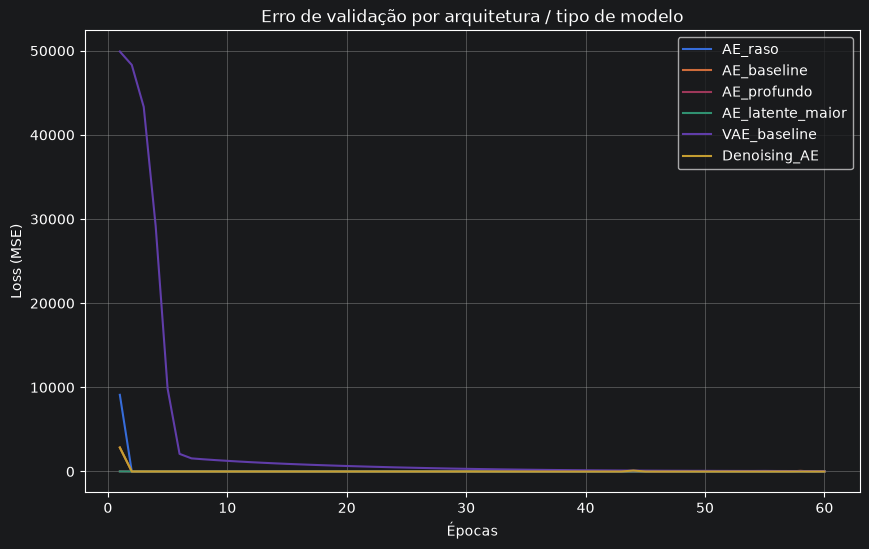

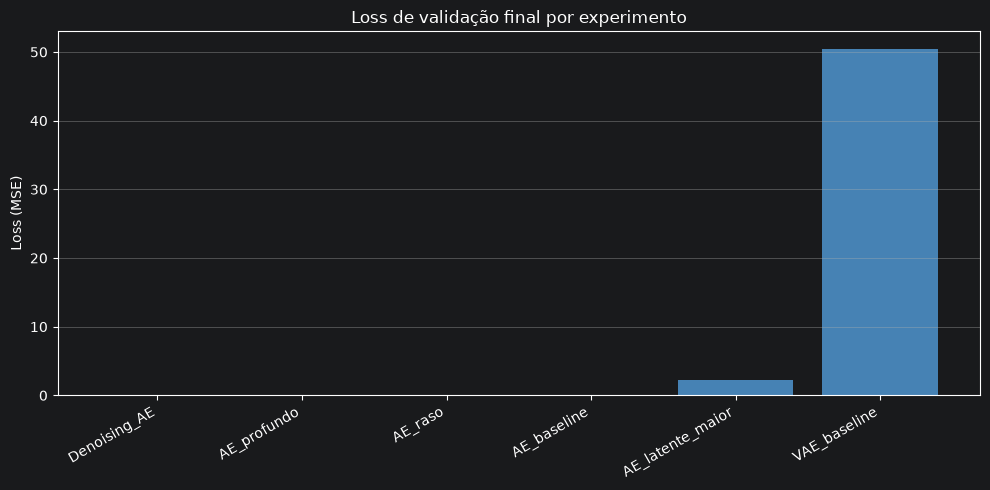

In [7]:
plt.figure(figsize=(10, 6))
for r in architecture_results:
    plt.plot(range(1, FIXED_EPOCHS + 1), r["history_val"], label=r["name"])
plt.title("Erro de validação por arquitetura / tipo de modelo")
plt.xlabel("Épocas")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(df_arch["name"], df_arch["final_val_loss"], color="steelblue")
plt.title("Loss de validação final por experimento")
plt.ylabel("Loss (MSE)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()
plt.show()


## 5. Etapa B — Busca de hiperparâmetros no melhor modelo

Pega a arquitetura/tipo de modelo vencedor da Etapa A (menor `final_val_loss`) e
varia `lr`, `batch_size` e `epochs` para ver o efeito de cada hiperparâmetro.


In [8]:
best_arch_cfg = min(architecture_configs, key=lambda c: next(
    r["final_val_loss"] for r in architecture_results if r["name"] == c["name"]
))
print(f"Melhor arquitetura da Etapa A: {best_arch_cfg['name']}")

learning_rates = [1e-2, 1e-3, 1e-4]
batch_sizes = [16, 32, 64]
epoch_options = [50, 100]

hp_results = []
for lr, bs, ep in itertools.product(learning_rates, batch_sizes, epoch_options):
    exp_name = f"{best_arch_cfg['name']}_lr{lr}_bs{bs}_ep{ep}"
    print(f"Treinando: {exp_name} ...")
    res = train_experiment(
        name=exp_name,
        model_type=best_arch_cfg["model_type"],
        hidden_dims=best_arch_cfg["hidden_dims"],
        latent_dim=best_arch_cfg["latent_dim"],
        lr=lr,
        batch_size=bs,
        epochs=ep,
        noise_std=best_arch_cfg.get("noise_std", 0.1),
    )
    hp_results.append(res)

print("Concluído!")


Melhor arquitetura da Etapa A: Denoising_AE
Treinando: Denoising_AE_lr0.01_bs16_ep50 ...
Treinando: Denoising_AE_lr0.01_bs16_ep100 ...
Treinando: Denoising_AE_lr0.01_bs32_ep50 ...
Treinando: Denoising_AE_lr0.01_bs32_ep100 ...
Treinando: Denoising_AE_lr0.01_bs64_ep50 ...
Treinando: Denoising_AE_lr0.01_bs64_ep100 ...
Treinando: Denoising_AE_lr0.001_bs16_ep50 ...
Treinando: Denoising_AE_lr0.001_bs16_ep100 ...
Treinando: Denoising_AE_lr0.001_bs32_ep50 ...
Treinando: Denoising_AE_lr0.001_bs32_ep100 ...
Treinando: Denoising_AE_lr0.001_bs64_ep50 ...
Treinando: Denoising_AE_lr0.001_bs64_ep100 ...
Treinando: Denoising_AE_lr0.0001_bs16_ep50 ...
Treinando: Denoising_AE_lr0.0001_bs16_ep100 ...
Treinando: Denoising_AE_lr0.0001_bs32_ep50 ...
Treinando: Denoising_AE_lr0.0001_bs32_ep100 ...
Treinando: Denoising_AE_lr0.0001_bs64_ep50 ...
Treinando: Denoising_AE_lr0.0001_bs64_ep100 ...
Concluído!


In [9]:
df_hp = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("history_train", "history_val", "model")}
    for r in hp_results
]).sort_values("final_val_loss").reset_index(drop=True)

df_hp

,name,model_type,hidden_dims,latent_dim,lr,batch_size,epochs,final_train_loss,final_val_loss,train_time_s
0,Denoising_AE_lr0.0001_bs16_ep100,denoising,"(16, 8)",4,0.0001,16,100,18.038785,0.000176,58.007814
1,Denoising_AE_lr0.001_bs16_ep100,denoising,"(16, 8)",4,0.0010,16,100,0.365294,0.000275,55.332105
2,Denoising_AE_lr0.0001_bs32_ep100,denoising,"(16, 8)",4,0.0001,32,100,19.898464,0.000984,32.891519
3,Denoising_AE_lr0.001_bs32_ep50,denoising,"(16, 8)",4,0.0010,32,50,0.162629,0.001781,14.283316
4,Denoising_AE_lr0.001_bs64_ep50,denoising,"(16, 8)",4,0.0010,64,50,0.012064,0.002926,6.551489
5,Denoising_AE_lr0.001_bs16_ep50,denoising,"(16, 8)",4,0.0010,16,50,1.746325,0.004239,28.685239
6,Denoising_AE_lr0.0001_bs64_ep100,denoising,"(16, 8)",4,0.0001,64,100,20.151959,0.011519,16.364951
7,Denoising_AE_lr0.01_bs64_ep50,denoising,"(16, 8)",4,0.0100,64,50,7.391317,0.013173,7.585852
8,Denoising_AE_lr0.01_bs64_ep100,denoising,"(16, 8)",4,0.0100,64,100,1.392755,0.014498,14.558852
9,Denoising_AE_lr0.0001_bs32_ep50,denoising,"(16, 8)",4,0.0001,32,50,20.176596,0.016702,16.929520


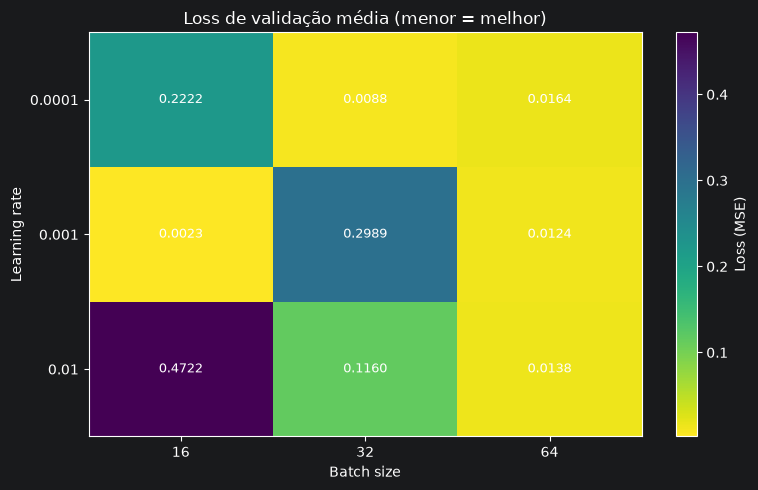

In [10]:
pivot = df_hp.pivot_table(index="lr", columns="batch_size", values="final_val_loss", aggfunc="mean")

plt.figure(figsize=(8, 5))
im = plt.imshow(pivot.values, cmap="viridis_r", aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("Batch size")
plt.ylabel("Learning rate")
plt.title("Loss de validação média (menor = melhor)")
plt.colorbar(im, label="Loss (MSE)")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        plt.text(j, i, f"{pivot.values[i, j]:.4f}", ha="center", va="center", color="white", fontsize=9)
plt.tight_layout()
plt.show()


## 6. Resultado final — todos os experimentos juntos

Junta a Etapa A e a Etapa B numa única tabela, escolhe o melhor experimento
geral e refaz a detecção de anomalias com ele.

In [11]:
all_results = architecture_results + hp_results

df_all = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("history_train", "history_val", "model")}
    for r in all_results
]).sort_values("final_val_loss").reset_index(drop=True)

print("Top 10 experimentos (menor loss de validação):")
df_all.head(10)


Top 10 experimentos (menor loss de validação):


,name,model_type,hidden_dims,latent_dim,lr,batch_size,epochs,final_train_loss,final_val_loss,train_time_s
0,Denoising_AE_lr0.0001_bs16_ep100,denoising,"(16, 8)",4,0.0001,16,100,18.038785,0.000176,58.007814
1,Denoising_AE_lr0.001_bs16_ep100,denoising,"(16, 8)",4,0.0010,16,100,0.365294,0.000275,55.332105
2,Denoising_AE_lr0.0001_bs32_ep100,denoising,"(16, 8)",4,0.0001,32,100,19.898464,0.000984,32.891519
3,Denoising_AE,denoising,"(16, 8)",4,0.0010,32,60,0.147951,0.001009,14.558675
4,Denoising_AE_lr0.001_bs32_ep50,denoising,"(16, 8)",4,0.0010,32,50,0.162629,0.001781,14.283316
5,Denoising_AE_lr0.001_bs64_ep50,denoising,"(16, 8)",4,0.0010,64,50,0.012064,0.002926,6.551489
6,AE_profundo,ae,"(32, 16, 8)",4,0.0010,32,60,0.603813,0.003125,18.724454
7,Denoising_AE_lr0.001_bs16_ep50,denoising,"(16, 8)",4,0.0010,16,50,1.746325,0.004239,28.685239
8,Denoising_AE_lr0.0001_bs64_ep100,denoising,"(16, 8)",4,0.0001,64,100,20.151959,0.011519,16.364951
9,Denoising_AE_lr0.01_bs64_ep50,denoising,"(16, 8)",4,0.0100,64,50,7.391317,0.013173,7.585852


In [12]:
best_result = min(all_results, key=lambda r: r["final_val_loss"])
best_model = best_result["model"]
best_model_type = best_result["model_type"]

print(f"Melhor experimento geral: {best_result['name']}")
print(f"  model_type={best_model_type} | hidden_dims={best_result['hidden_dims']} | "
      f"latent_dim={best_result['latent_dim']} | lr={best_result['lr']} | "
      f"batch_size={best_result['batch_size']} | epochs={best_result['epochs']}")
print(f"  final_val_loss={best_result['final_val_loss']:.6f}")


Melhor experimento geral: Denoising_AE_lr0.0001_bs16_ep100
  model_type=denoising | hidden_dims=(16, 8) | latent_dim=4 | lr=0.0001 | batch_size=16 | epochs=100
  final_val_loss=0.000176


In [13]:
best_model.eval()
with torch.no_grad():
    all_test_data = test_dataset[:][0].to(device)
    if best_model_type == "vae":
        reconstructions, _, _ = best_model(all_test_data)
    elif best_model_type == "denoising":
        reconstructions = best_model(all_test_data, add_noise=False)
    else:
        reconstructions = best_model(all_test_data)
    errors = torch.mean((all_test_data - reconstructions) ** 2, dim=1).cpu().numpy()

threshold = np.percentile(errors, 95)
anomalies = errors > threshold
total_anomalies = np.sum(anomalies)

print(f"Modelo usado: {best_result['name']}")
print(f"Limiar Dinâmico (Percentil 95): {threshold:.6f}")
print(f"Total de anomalias encontradas: {total_anomalies} de {len(all_test_data)}")


Modelo usado: Denoising_AE_lr0.0001_bs16_ep100
Limiar Dinâmico (Percentil 95): 0.000342
Total de anomalias encontradas: 58 de 1231


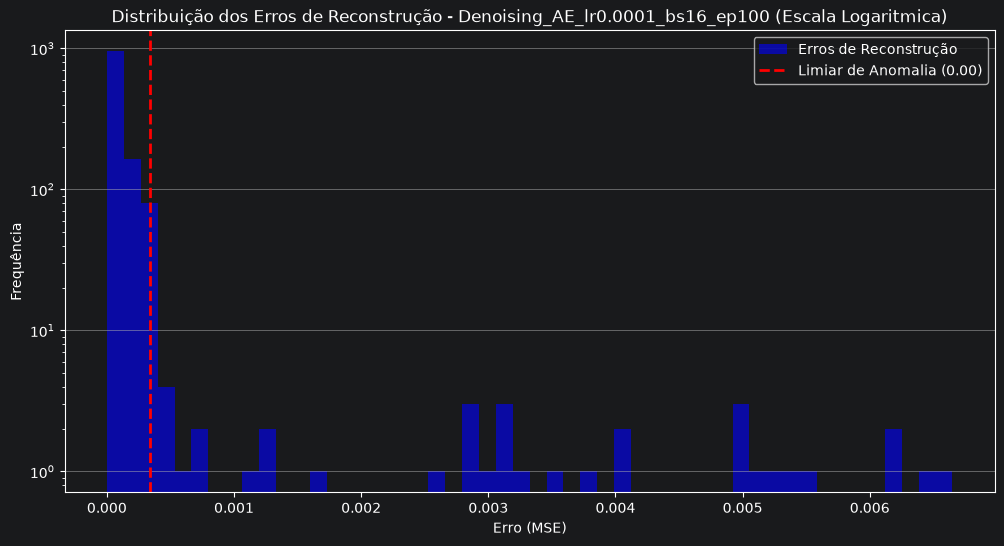

In [14]:
plt.figure(figsize=(12, 6))

plt.hist(errors, bins=50, color="blue", alpha=0.6, label="Erros de Reconstrução")
plt.axvline(x=threshold, color="red", linestyle="dashed", linewidth=2, label=f"Limiar de Anomalia ({threshold:.2f})")

plt.yscale("log")
plt.title(f"Distribuição dos Erros de Reconstrução - {best_result['name']} (Escala Logaritmica)")
plt.xlabel("Erro (MSE)")
plt.ylabel("Frequência")
plt.legend()
plt.grid(axis="y", alpha=0.7)
plt.show()


## 7. Conclusões

**Arquitetura dos modelos (Etapa A).** O **Denoising_AE** apresentou o melhor desempenho, com *val_loss* de **0.001009**, superando os demais modelos. Apesar de o **AE_baseline** ter obtido a menor *train_loss*, seu desempenho na validação foi inferior, o que era esperado, já que o Denoising_AE é treinado para reconstruir entradas com ruído. O aumento do espaço latente para 8 dimensões prejudicou os resultados, indicando que quatro dimensões já eram suficientes para o problema. O **VAE** apresentou o pior desempenho, mas sua função de perda não é diretamente comparável às dos outros modelos.

**Learning rate e batch size (Etapa B).** A melhor configuração foi **learning rate = 0.0001**, **batch size = 16** e **100 épocas**, alcançando *val_loss* de **0.000176**. Em geral, taxas de aprendizado menores e batches menores produziram melhores resultados, enquanto **lr = 0.01** apresentou a pior convergência.

**Detecção de anomalias.** Utilizando o melhor modelo, o limiar definido pelo percentil 95 classificou **58 das 1231 amostras** (4,7%) como anômalas. A distribuição dos erros mostrou uma separação clara entre amostras normais e a cauda de maiores erros, indicando que o modelo conseguiu identificar padrões atípicos de forma consistente.

**Tempo de treinamento.** A melhor configuração também foi a mais lenta, levando cerca de **58 segundos** para treinar. Em contrapartida, a configuração **lr = 0.001**, **batch size = 64** e **50 épocas** treinou em apenas **6,55 segundos** e apresentou um desempenho competitivo, oferecendo uma boa relação entre tempo de treinamento e qualidade dos resultados.


## 8. Extra

In [18]:
top10 = df_all.head(10)

all_test_data = test_dataset[:][0].to(device)

best_name = top10.iloc[0]["name"]
best_result = next(r for r in all_results if r["name"] == best_name)

best_model = best_result["model"]
best_model.eval()

with torch.no_grad():

    if best_result["model_type"] == "vae":
        recon, _, _ = best_model(all_test_data)
    elif best_result["model_type"] == "denoising":
        recon = best_model(all_test_data, add_noise=False)
    else:
        recon = best_model(all_test_data)

best_errors = torch.mean((all_test_data - recon) ** 2, dim=1).cpu().numpy()

reference_threshold = np.percentile(best_errors, 95)

print(f"Limiar de referência: {reference_threshold:.8f}")

comparison = []

for _, row in top10.iterrows():

    result = next(r for r in all_results if r["name"] == row["name"])
    model = result["model"]

    model.eval()

    with torch.no_grad():

        if result["model_type"] == "vae":
            recon, _, _ = model(all_test_data)

        elif result["model_type"] == "denoising":
            recon = model(all_test_data, add_noise=False)

        else:
            recon = model(all_test_data)

        errors = torch.mean((all_test_data - recon) ** 2, dim=1).cpu().numpy()

    anomalies = errors > reference_threshold

    comparison.append({
        "Modelo": result["name"],
        "Val Loss": result["final_val_loss"],
        "Erro médio": errors.mean(),
        "Erro máximo": errors.max(),
        "Anomalias": anomalies.sum()
    })

df_compare = pd.DataFrame(comparison).sort_values("Val Loss")

display(df_compare)

Limiar de referência: 0.00034244


,Modelo,Val Loss,Erro médio,Erro máximo,Anomalias
0,Denoising_AE_lr0.0001_bs16_ep100,0.000176,0.000176,0.006649,58
1,Denoising_AE_lr0.001_bs16_ep100,0.000275,0.000275,0.014664,120
2,Denoising_AE_lr0.0001_bs32_ep100,0.000984,0.000991,0.018893,525
3,Denoising_AE,0.001009,0.001022,0.028419,204
4,Denoising_AE_lr0.001_bs32_ep50,0.001781,0.001791,0.022657,1108
5,Denoising_AE_lr0.001_bs64_ep50,0.002926,0.002968,0.046551,416
6,AE_profundo,0.003125,0.003151,0.145426,476
7,Denoising_AE_lr0.001_bs16_ep50,0.004239,0.004239,0.064654,1098
8,Denoising_AE_lr0.0001_bs64_ep100,0.011519,0.011952,0.177183,935
9,Denoising_AE_lr0.01_bs64_ep50,0.013173,0.013618,0.183668,435


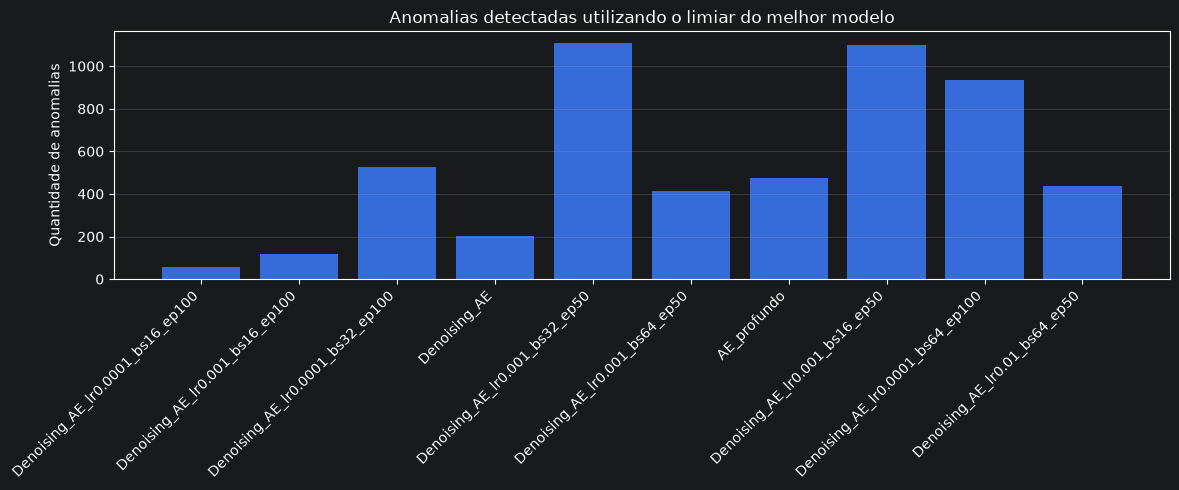

In [19]:
plt.figure(figsize=(12,5))

plt.bar(df_compare["Modelo"], df_compare["Anomalias"])

plt.xticks(rotation=45, ha="right")
plt.ylabel("Quantidade de anomalias")
plt.title("Anomalias detectadas utilizando o limiar do melhor modelo")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Os 10 melhores modelos foram comparados utilizando o mesmo limiar de detecção, definido pelo melhor modelo. De forma geral, observou-se que modelos com menor validation loss tendem a detectar menos anomalias, enquanto modelos com pior capacidade de reconstrução classificam uma quantidade maior de amostras como anômalas.

Como este é um problema de aprendizado não supervisionado, não existe um rótulo indicando quais amostras são realmente anômalas. Assim, não é possível afirmar que um modelo é melhor apenas por detectar mais ou menos anomalias. O objetivo da detecção é funcionar como uma luz de alerta, destacando amostras que merecem uma análise mais detalhada por um especialista.

Dessa forma, a comparação entre os modelos mostra principalmente sua sensibilidade às diferenças nos dados. O melhor modelo apresentou um comportamento mais conservador, detectando 58 possíveis anomalias, enquanto modelos com maior erro de reconstrução chegaram a sinalizar mais de 1100 amostras, indicando uma tendência maior à geração de alertas.